<a href="https://colab.research.google.com/github/aryanp2107/Deep_Learning/blob/main/Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

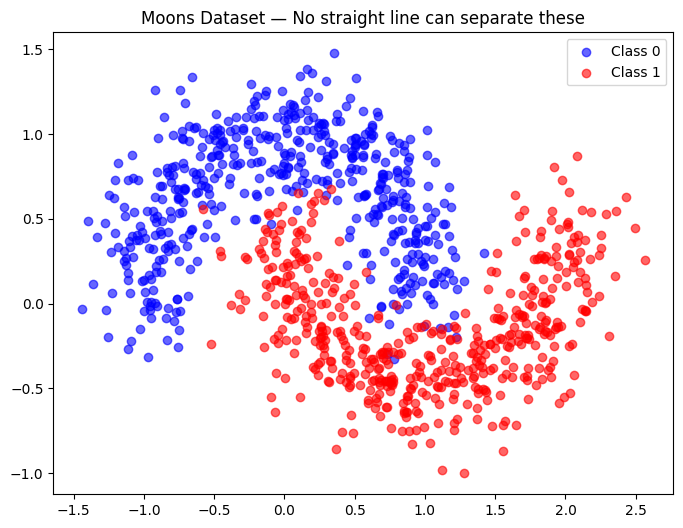

In [ ]:
x, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(x[y==0, 0], x[y==0, 1], c='blue', alpha=0.6, label='Class 0')
plt.scatter(x[y==1, 0], x[y==1, 1], c='red', alpha=0.6, label='Class 1')
plt.title('Moons Dataset — No straight line can separate these')
plt.legend()
plt.show()

In [ ]:
#Tensors
a = torch.tensor([1, 2, 3])
b = torch.randn(3, 4)
c = torch.zeros(2, 2)

print(f'Tensor: {a}')
print(f"Shape: {b.shape}")
print(f"Data type: {c.dtype}")
print(f"Device: {c.device}")

Tensor: tensor([1, 2, 3])
Shape: torch.Size([3, 4])
Data type: torch.float32
Device: cpu


In [ ]:
np_array = np.array([1.0, 2.0, 3.0])
tensor = torch.from_numpy(np_array).float()
back_to_numpy = tensor.numpy()

print(f"Numpy to Tensor: {tensor}")
print(f"Tensor to Numpy: {back_to_numpy}")

Numpy to Tensor: tensor([1., 2., 3.])
Tensor to Numpy: [1. 2. 3.]


In [ ]:
# Method 1: nn.Sequential (quick and simple)
model_simple = nn.Sequential(
    nn.Linear(2, 16),   # Input → Hidden
    nn.ReLU(),          # Activation
    nn.Linear(16, 8),   # Hidden → Hidden
    nn.ReLU(),
    nn.Linear(8, 1),    # Hidden → Output
    nn.Sigmoid()        # Binary classification
)

print("Sequential model:")
print(model_simple)

Sequential model:
Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


In [ ]:
#Method 2: nn.Module Class (more flexible)
class NeuralNet(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.layer1 = nn.Linear(input_size, hidden_size)
    self.layer2 = nn.Linear(hidden_size, hidden_size // 2)
    self.layer3 = nn.Linear(hidden_size // 2, output_size)
    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x = self.relu(self.layer1(x))
    x = self.relu(self.layer2(x))
    x = self.sigmoid(self.layer3(x))
    return x

model = NeuralNet(input_size=2, hidden_size=16, output_size=1)
print("Custom model:")
print(model)

Custom model:
NeuralNet(
  (layer1): Linear(in_features=2, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 193


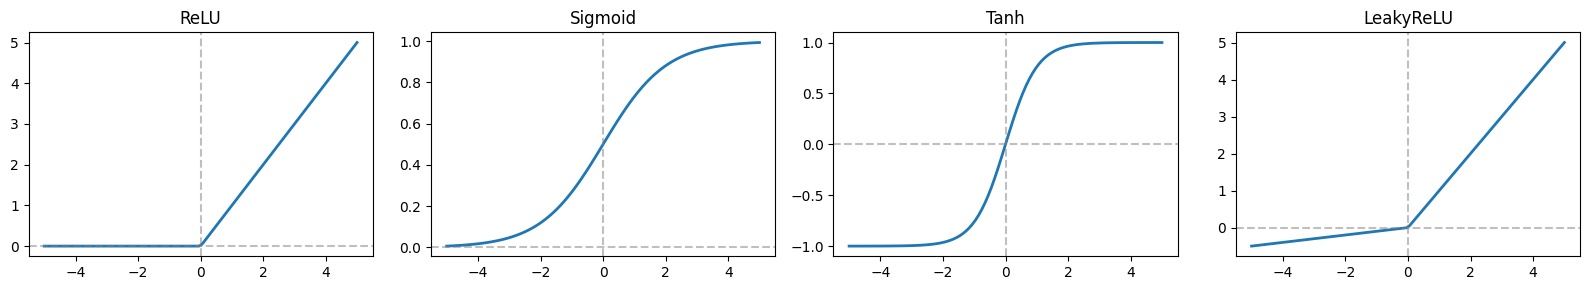

Rule of thumb:
  • Hidden layers: ReLU (or LeakyReLU)
  • Output (binary): Sigmoid
  • Output (multi-class): Softmax
  • Output (regression): None (linear)


In [ ]:
# Common activations
x = torch.linspace(-5, 5, 100)

activations = {
    'ReLU': nn.ReLU(),
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh(),
    'LeakyReLU': nn.LeakyReLU(0.1)
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, (name, fn) in zip(axes, activations.items()):
    ax.plot(x.numpy(), fn(x).numpy(), linewidth=2)
    ax.set_title(name)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Rule of thumb:")
print("  • Hidden layers: ReLU (or LeakyReLU)")
print("  • Output (binary): Sigmoid")
print("  • Output (multi-class): Softmax")
print("  • Output (regression): None (linear)")

In [ ]:
# Training Loop
x, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#Convert to tensors
x_train_t = torch.FloatTensor(x_train)
y_train_t = torch.FloatTensor(y_train).reshape(-1, 1)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.FloatTensor(y_test).reshape(-1, 1)

print(f"Train: {x_train_t.shape}, Test: {x_test_t.shape}")

Train: torch.Size([800, 2]), Test: torch.Size([200, 2])


In [ ]:
#Creating a fresh model
model = NeuralNet(2, 16, 1)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
#Training Loop
epochs = 500
losses = []

for epoch in range(epochs):
  #Forward Pass
  model.train()
  outputs = model(x_train_t)
  loss = criterion(outputs, y_train_t)

  #Backward Pass
  optimizer.zero_grad()   #Clear gradients
  loss.backward()         #Computer gradients
  optimizer.step()        #Update weights

  losses.append(loss.item())

  if epoch % 100 == 0:
    acc = ((outputs > 0.5) == y_train_t).float().mean()
    print(f"Epoch: {epoch}, Loss: {loss.item():.4f}, Acc: {acc.item():.4f}")

Epoch: 0, Loss: 0.6556, Acc: 0.5000
Epoch: 100, Loss: 0.0865, Acc: 0.9725
Epoch: 200, Loss: 0.0638, Acc: 0.9750
Epoch: 300, Loss: 0.0603, Acc: 0.9775
Epoch: 400, Loss: 0.0584, Acc: 0.9787


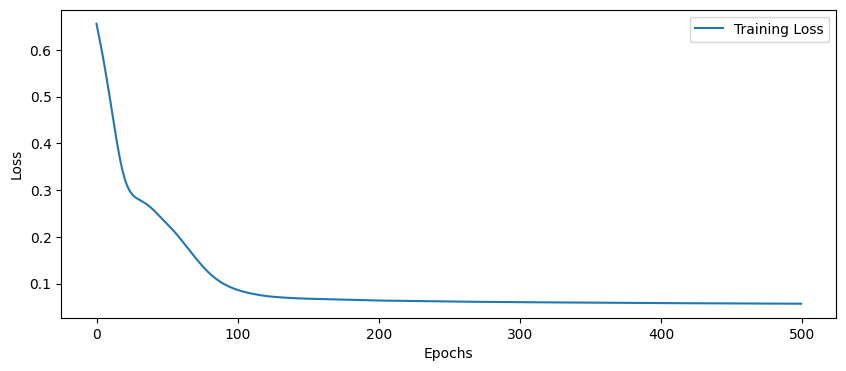

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(losses, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
#Evaluate
model.eval()
with torch.no_grad():
  y_pred = (model(x_test_t) > 0.5).float()
  test_acc = (y_pred == y_test_t).float().mean()

print(f"Test Accuracy: {test_acc.item():.4f}")

Test Accuracy: 0.9900


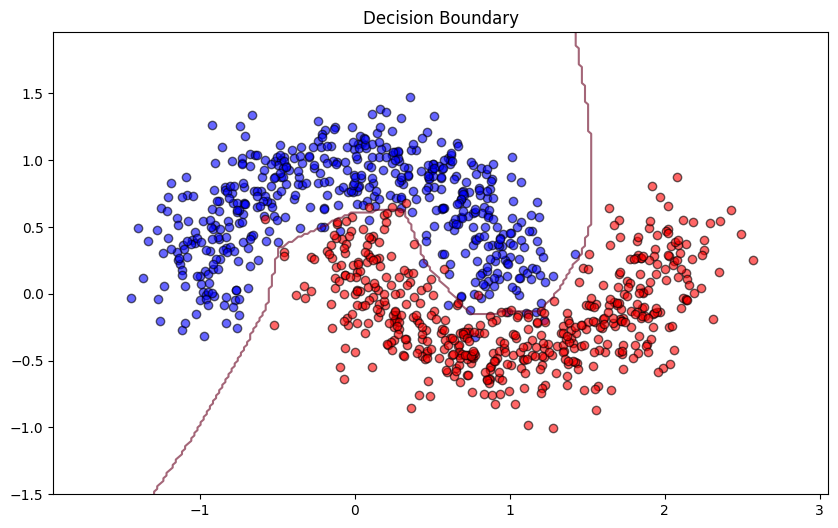

In [ ]:
# Visualizing the decision boundary
def plot_decision_boundary(model, x, y, scaler):
  h = 0.02
  x_min, x_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
  y_min, y_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

  grid = np.c_[xx.ravel(), yy.ravel()]
  grid_scaled = scaler.transform(grid)
  grid_t = torch.FloatTensor(grid_scaled)

  model.eval()
  with torch.no_grad():
    z = (model(grid_t) > 0.5).numpy().reshape(xx.shape)

  plt.figure(figsize=(10, 6))
  plt.contour(xx, yy, z, alpha=0.6, cmap='RdBu')
  plt.scatter(x[y==0, 0], x[y==0, 1], c='blue', edgecolors='black', alpha=0.6)
  plt.scatter(x[y==1, 0], x[y==1, 1], c='red', edgecolors='black', alpha=0.6)
  plt.title("Decision Boundary")
  plt.show()

x_orig, y_orig = make_moons(n_samples=1000, noise=0.2, random_state=42)
plot_decision_boundary(model, x_orig, y_orig, scaler)

DataLoader (Batch Training)

In [ ]:
# The DataLoader handles batch training automatically
train_dataset = TensorDataset(x_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Dataset size: {len(train_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")
print(f"Batch size: {train_loader.batch_size}")

Dataset size: 800
Batches per epoch: 25
Batch size: 32


In [ ]:
#Training with batches
model2 = NeuralNet(2, 16, 1)
criterion = nn.BCELoss()
optimizer = optim.Adam(model2.parameters(), lr=0.01)

epochs = 100

for epoch in range(epochs):
  model2.train()
  epoch_loss = 0

  for batch_x, batch_y in train_loader:
    outputs = model2(batch_x)
    loss = criterion(outputs, batch_y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()

  if epoch % 20 == 0:
    print(f"Epoch: {epoch}, Loss: {epoch_loss / len(train_loader):.4f}")

#Evaluation
model2.eval()
with torch.no_grad():
  test_acc = ((model2(x_test_t) > 0.5) == y_test_t).float().mean()
print(f"\nTest Accuracy: {test_acc:.2%}")

Epoch: 0, Loss: 0.6283
Epoch: 20, Loss: 0.0802
Epoch: 40, Loss: 0.0763
Epoch: 60, Loss: 0.0788
Epoch: 80, Loss: 0.0717

Test Accuracy: 98.50%


Multi-class Classification: Dry Bean

In [ ]:
import requests, zipfile, io
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00602/DryBeanDataset.zip"
r = requests.get(url)
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
  with z.open('DryBeanDataset/Dry_Bean_Dataset.xlsx') as f:
      df = pd.read_excel(f)
print(f"Loaded Dry Bean: {df.shape}")

Loaded Dry Bean: (13611, 17)


In [ ]:
df.head(-20)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13586,41875,760.096,287.817788,185.586855,1.550852,0.764346,42172,230.904539,0.800088,0.992957,0.910810,0.802259,0.006873,0.001756,0.643620,0.998160,DERMASON
13587,41888,789.822,299.271436,179.534078,1.666934,0.800072,42668,230.940378,0.669202,0.981719,0.843803,0.771675,0.007145,0.001563,0.595483,0.992630,DERMASON
13588,41889,784.724,294.558979,181.575824,1.622237,0.787408,42560,230.943134,0.753657,0.984234,0.854823,0.784030,0.007032,0.001639,0.614703,0.997194,DERMASON
13589,41941,770.196,292.619889,183.362076,1.595858,0.779323,42390,231.086433,0.710094,0.989408,0.888477,0.789715,0.006977,0.001674,0.623650,0.995258,DERMASON


In [ ]:
from sklearn.preprocessing import LabelEncoder
x_beans = df.drop('Class', axis=1).values
y_beans = df['Class'].values

if isinstance(y_beans[0], str):
  y_beans = LabelEncoder().fit_transform(y_beans)

n_classes = len(np.unique(y_beans))
n_features = x_beans.shape[1]

print(f"Features: {n_features}, classes: {n_classes}")

Features: 16, classes: 7


In [ ]:
x_train_b, x_test_b, y_train_b, y_test_b = train_test_split(x_beans, y_beans, test_size=0.2, random_state=42, stratify=y_beans)

scaler_b = StandardScaler()
x_train_b = scaler_b.fit_transform(x_train_b)
x_test_b = scaler_b.transform(x_test_b)

#Tensors
x_train_bt = torch.FloatTensor(x_train_b)
x_test_bt = torch.FloatTensor(x_test_b)
y_train_bt = torch.LongTensor(y_train_b)
y_test_bt = torch.LongTensor(y_test_b)

#DataLoader
train_loader_b = DataLoader(TensorDataset(x_train_bt, y_train_bt), batch_size=64, shuffle=True)

In [ ]:
class MultiClassNet(nn.Module):
  def __init__(self, n_features, n_classes):
    super().__init__()
    self.net = nn.Sequential(
          nn.Linear(n_features, 64),
          nn.ReLU(),
          nn.Dropout(0.3),
          nn.Linear(64, 32),
          nn.ReLU(),
          nn.Dropout(0.3),
          nn.Linear(32, n_classes),
    )
  def forward(self, x):
    return self.net(x)

model_mc = MultiClassNet(n_features, n_classes)
print(model_mc)

MultiClassNet(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=7, bias=True)
  )
)


In [ ]:
#Train
criterion_mc = nn.CrossEntropyLoss()
optimizer_mc = optim.Adam(model_mc.parameters(), lr=0.01)

epochs = 100

for epoch in range(epochs):
  model_mc.train()
  epoch_loss = 0

  for batch_x, batch_y in train_loader_b:
    outputs = model_mc(batch_x)
    loss = criterion_mc(outputs, batch_y)

    optimizer_mc.zero_grad()
    loss.backward()
    optimizer_mc.step()

    epoch_loss += loss.item()

  if epoch % 20 == 0:
    model_mc.eval()
    with torch.no_grad():
      _, preds = torch.max(model_mc(x_train_bt), 1)
      acc = (preds == y_train_bt).float().mean()

    print(f"Epoch: {epoch:3d} | Loss: {epoch_loss/len(train_loader_b):.4f} | Acc: {acc:.2%}")

Epoch:   0 | Loss: 0.2768 | Acc: 93.42%
Epoch:  20 | Loss: 0.2359 | Acc: 92.15%
Epoch:  40 | Loss: 0.2280 | Acc: 93.30%
Epoch:  60 | Loss: 0.2380 | Acc: 93.37%
Epoch:  80 | Loss: 0.2511 | Acc: 92.97%


In [ ]:
#Evaluate
model_mc.eval()
with torch.no_grad():
  outputs = model_mc(x_test_bt)
  _, predictions = torch.max(outputs, 1)
  test_acc = (predictions == y_test_bt).float().mean()

print(f"Test Accuracy: {test_acc:.2%}")
print("Classification Report:")
print(classification_report(y_test_bt, predictions.numpy()))


Test Accuracy: 92.43%
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       265
           1       1.00      1.00      1.00       104
           2       0.94      0.94      0.94       326
           3       0.91      0.92      0.92       709
           4       0.96      0.96      0.96       386
           5       0.92      0.97      0.95       406
           6       0.89      0.85      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723

